## EDA

подключаем бибилиотеки

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from datetime import timedelta
from sklearn.metrics.pairwise import cosine_similarity
import rectools
from rectools import Columns, dataset

Загружаем данные

In [2]:
users = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/data_original/users.csv')
items = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/data_original/items.csv')
interactions = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/interactions.csv')

In [3]:
interactions.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250.0,72.0
1,699317,1659,2021-05-29,8317.0,100.0
2,656683,7107,2021-05-09,10.0,0.0
3,864613,7638,2021-07-05,14483.0,100.0
4,964868,9506,2021-04-30,6725.0,100.0


In [4]:
users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [5]:
items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


смотрим пропуски и типы данных

In [6]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594787 entries, 0 to 1594786
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   user_id        1594787 non-null  int64  
 1   item_id        1594787 non-null  int64  
 2   last_watch_dt  1594787 non-null  object 
 3   total_dur      1594786 non-null  float64
 4   watched_pct    1594519 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 60.8+ MB


In [7]:
interactions.isnull().sum()

user_id            0
item_id            0
last_watch_dt      0
total_dur          1
watched_pct      268
dtype: int64

In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   840197 non-null  int64 
 1   age       826102 non-null  object
 2   income    825421 non-null  object
 3   sex       826366 non-null  object
 4   kids_flg  840197 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 32.1+ MB


In [9]:
users.isnull().sum()

user_id         0
age         14095
income      14776
sex         13831
kids_flg        0
dtype: int64

In [10]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 non-null  float64
 9   studios       1065 non-null   object 
 10  directors     14454 non-null  object 
 11  actors        13344 non-null  object 
 12  description   15961 non-null  object 
 13  keywords      15540 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 1.7+ MB


In [11]:
items.isnull().sum()

item_id             0
content_type        0
title               0
title_orig       4745
release_year       98
genres              0
countries          37
for_kids        15397
age_rating          2
studios         14898
directors        1509
actors           2619
description         2
keywords          423
dtype: int64

количество пользователей и фильмов

In [12]:
print('Зарегистрированных пользователей: ',  len(users['user_id'].unique()), 
      'Пользователей с просмотрами: ', len(interactions['user_id'].unique()), sep='\n')

Зарегистрированных пользователей: 
840197
Пользователей с просмотрами: 
567588


In [13]:
print('Всего фильмов: ',  len(items['item_id'].unique()), 
      'Фильмы с просмотрами: ', len(interactions['item_id'].unique()), sep='\n')

Всего фильмов: 
15963
Фильмы с просмотрами: 
12693


процент просмотров

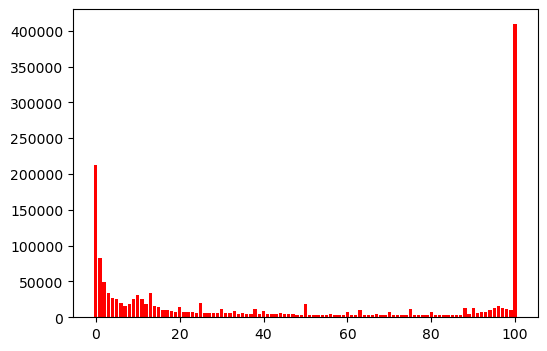

In [14]:
watch = interactions['watched_pct'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(watch.index, watch, color='red')
plt.show()

In [15]:
interactions['last_watch_dt'].unique()
interactions['last_watch_dt'] = pd.to_datetime(interactions['last_watch_dt'], format='%Y-%m-%d', errors='coerce')
interactions = interactions.dropna(subset=['last_watch_dt'])
interactions.isnull().sum()

user_id            0
item_id            0
last_watch_dt      0
total_dur          0
watched_pct      267
dtype: int64

смотрим временной промежуток данных

In [16]:
print(interactions['last_watch_dt'].min(), interactions['last_watch_dt'].max())

2021-03-13 00:00:00 2021-08-22 00:00:00


количество и время просмотров по месяцам

In [17]:
monthly = interactions.groupby(pd.Grouper(key='last_watch_dt', freq='M')).agg({
    'user_id': 'count',
    'total_dur': 'sum'
}).rename(columns={'user_id': 'total_interactions'})
monthly

/var/folders/qs/gxy4f99x26l7w88l0zk12_w00000gn/T/ipykernel_1728/320462991.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = interactions.groupby(pd.Grouper(key='last_watch_dt', freq='M')).agg({


,total_interactions,total_dur
last_watch_dt,,
2021-03-31,77213,4.601695e+08
2021-04-30,149717,8.979473e+08
2021-05-31,221713,1.634697e+09
2021-06-30,348872,3.612364e+09
2021-07-31,427045,3.993559e+09
2021-08-31,370226,2.598928e+09


количество и время просмотров по дням

In [18]:
day = interactions.groupby(pd.Grouper(key='last_watch_dt', freq='D')).agg({
    'user_id': 'count',
    'total_dur': 'sum'
}).rename(columns={'user_id': 'total_interactions'})
day

,total_interactions,total_dur
last_watch_dt,,
2021-03-13,4701,29346483.0
2021-03-14,4494,29502382.0
2021-03-15,3768,25780151.0
2021-03-16,3767,23211596.0
2021-03-17,3793,24194580.0
...,...,...
2021-08-18,16478,110727107.0
2021-08-19,17155,119043076.0
2021-08-20,17521,116506997.0


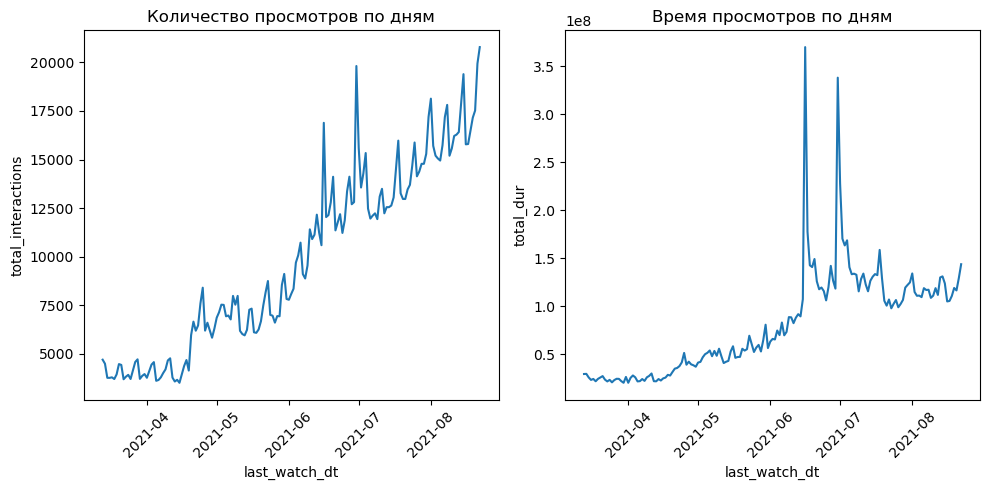

In [19]:
plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.xticks(rotation=45)
sns.lineplot(data=day, x='last_watch_dt', y='total_interactions')
plt.title('Количество просмотров по дням')

plt.subplot(1, 2, 2)
plt.xticks(rotation=45)
sns.lineplot(data=day, x='last_watch_dt', y='total_dur')
plt.title('Время просмотров по дням')

plt.tight_layout()
plt.show()

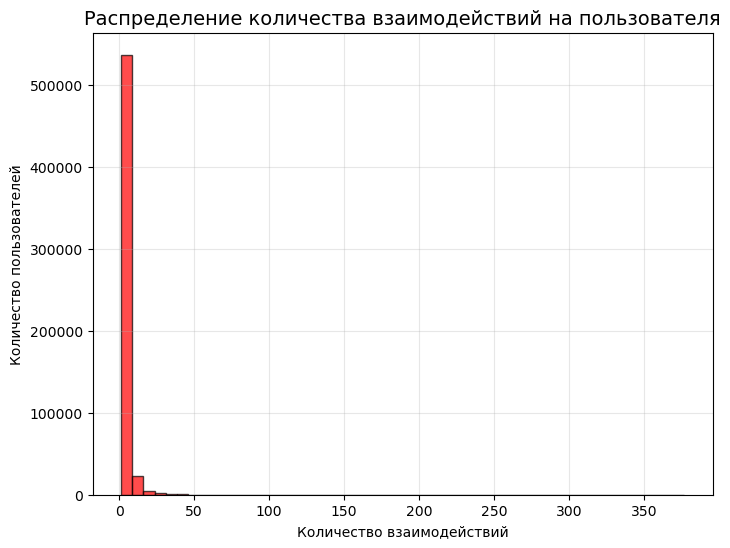

In [20]:
user_activity = interactions.groupby('user_id').size().reset_index(name='interactions_count')

plt.figure(figsize=(8, 6))
plt.hist(user_activity['interactions_count'], bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('Распределение количества взаимодействий на пользователя', fontsize=14)
plt.xlabel('Количество взаимодействий')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.3)
plt.show()

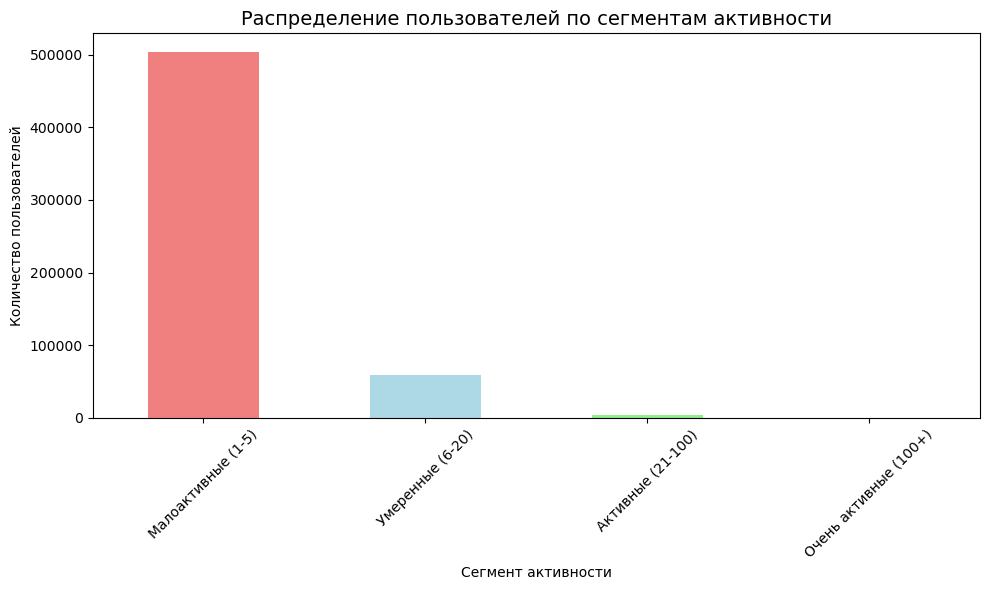


Распределение по сегментам активности:
activity_segment
Малоактивные (1-5)       504361
Умеренные (6-20)          58846
Активные (21-100)          4346
Очень активные (100+)        35
Name: count, dtype: int64


In [21]:
def categorize_activity(count):
    if 1 <= count <= 5:
        return 'Малоактивные (1-5)'
    elif 5 < count <= 20:
        return 'Умеренные (6-20)'
    elif 20 < count <= 100:
        return 'Активные (21-100)'
    else:
        return 'Очень активные (100+)'

user_activity['activity_segment'] = user_activity['interactions_count'].apply(categorize_activity)

segment_counts = user_activity['activity_segment'].value_counts()

plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color=['lightcoral', 'lightblue', 'lightgreen', 'gold'])
plt.title('Распределение пользователей по сегментам активности', fontsize=14)
plt.xlabel('Сегмент активности')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nРаспределение по сегментам активности:")
print(segment_counts)

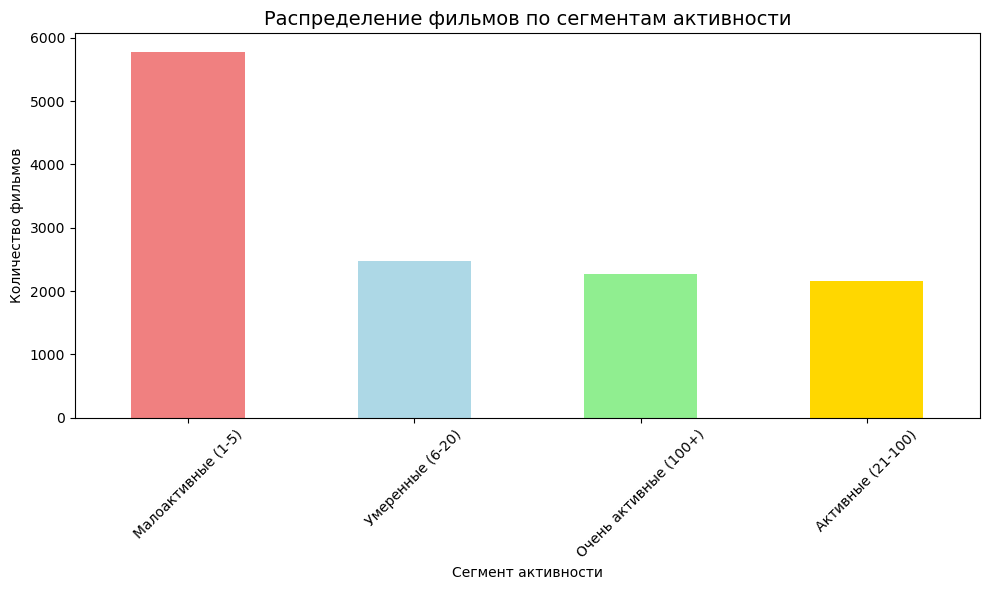


Распределение по сегментам активности:
activity_segment
Малоактивные (1-5)       5782
Умеренные (6-20)         2468
Очень активные (100+)    2276
Активные (21-100)        2167
Name: count, dtype: int64


In [22]:
item_activity = interactions.groupby('item_id').size().reset_index(name='interactions_count')
def categorize_activity(count):
    if 1 <= count <= 5:
        return 'Малоактивные (1-5)'
    elif 5 < count <= 20:
        return 'Умеренные (6-20)'
    elif 20 < count <= 100:
        return 'Активные (21-100)'
    else:
        return 'Очень активные (100+)'

item_activity['activity_segment'] = item_activity['interactions_count'].apply(categorize_activity)

segment_counts_item = item_activity['activity_segment'].value_counts()

plt.figure(figsize=(10, 6))
segment_counts_item.plot(kind='bar', color=['lightcoral', 'lightblue', 'lightgreen', 'gold'])
plt.title('Распределение фильмов по сегментам активности', fontsize=14)
plt.xlabel('Сегмент активности')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nРаспределение по сегментам активности:")
print(segment_counts_item)

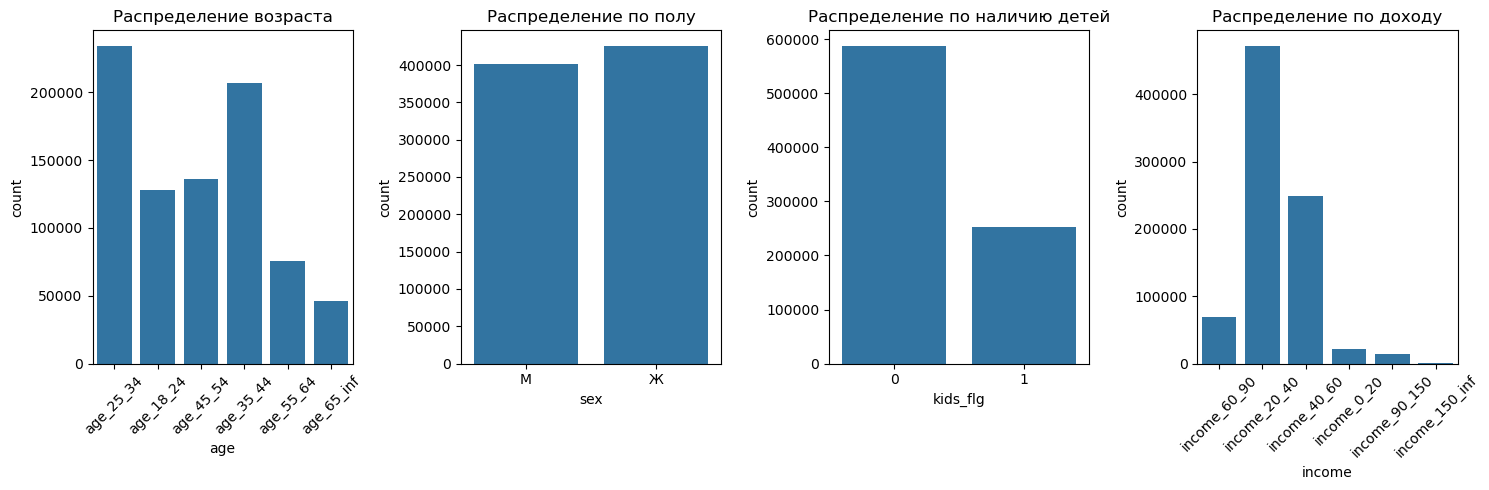

In [23]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.xticks(rotation=45)
sns.countplot(x=users['age'])
plt.title('Распределение возраста')

plt.subplot(1, 4, 2)
sns.countplot(x=users['sex'])
plt.title('Распределение по полу')

plt.subplot(1, 4, 3)
sns.countplot(x=users['kids_flg'])
plt.title('Распределение по наличию детей')

plt.subplot(1, 4, 4)
plt.xticks(rotation=45)
sns.countplot(x=users['income'])
plt.title('Распределение по доходу')

plt.tight_layout()
plt.show()

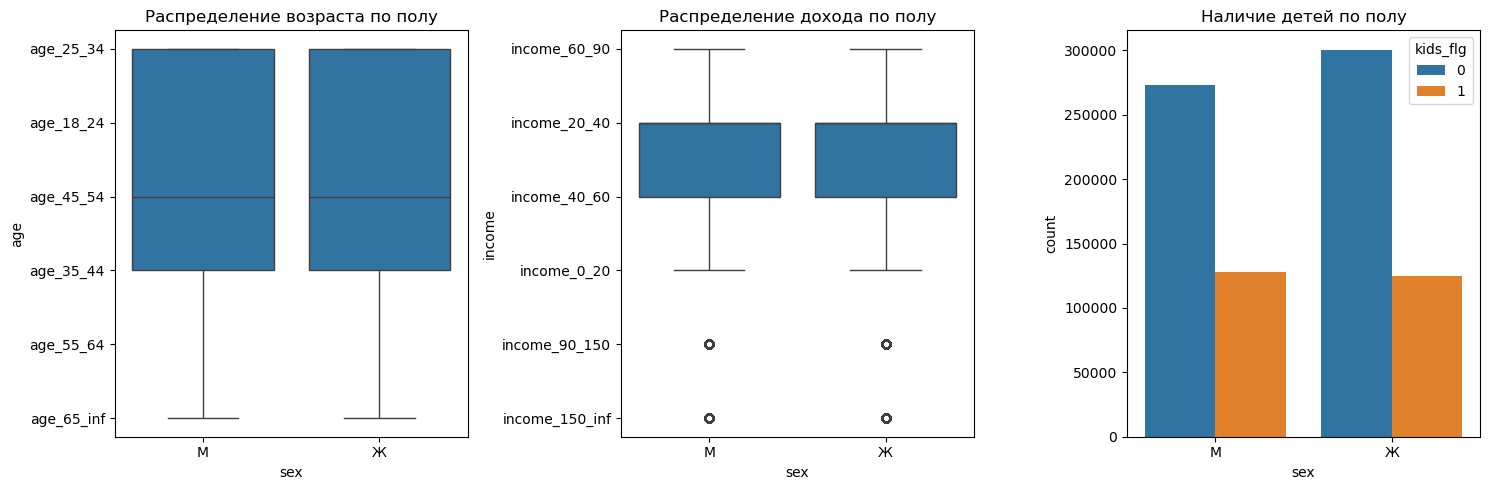

In [24]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=users, x='sex', y='age')
plt.title('Распределение возраста по полу')

plt.subplot(1, 3, 2)
sns.boxplot(data=users, x='sex', y='income')
plt.title('Распределение дохода по полу')

plt.subplot(1, 3, 3)
sns.countplot(data=users, x=users['sex'], hue=users['kids_flg'])
plt.title('Наличие детей по полу')

plt.tight_layout()
plt.show()

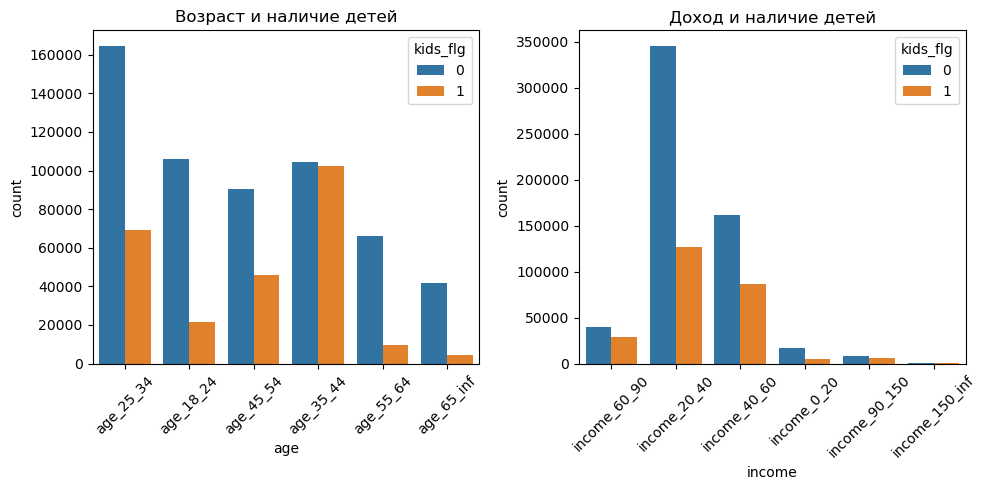

In [25]:
plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.xticks(rotation=45)
sns.countplot(data=users, x='age', hue='kids_flg')
plt.title('Возраст и наличие детей')

plt.subplot(1, 2, 2)
plt.xticks(rotation=45)
sns.countplot(data=users, x='income', hue='kids_flg')
plt.title('Доход и наличие детей')

plt.tight_layout()
plt.show()

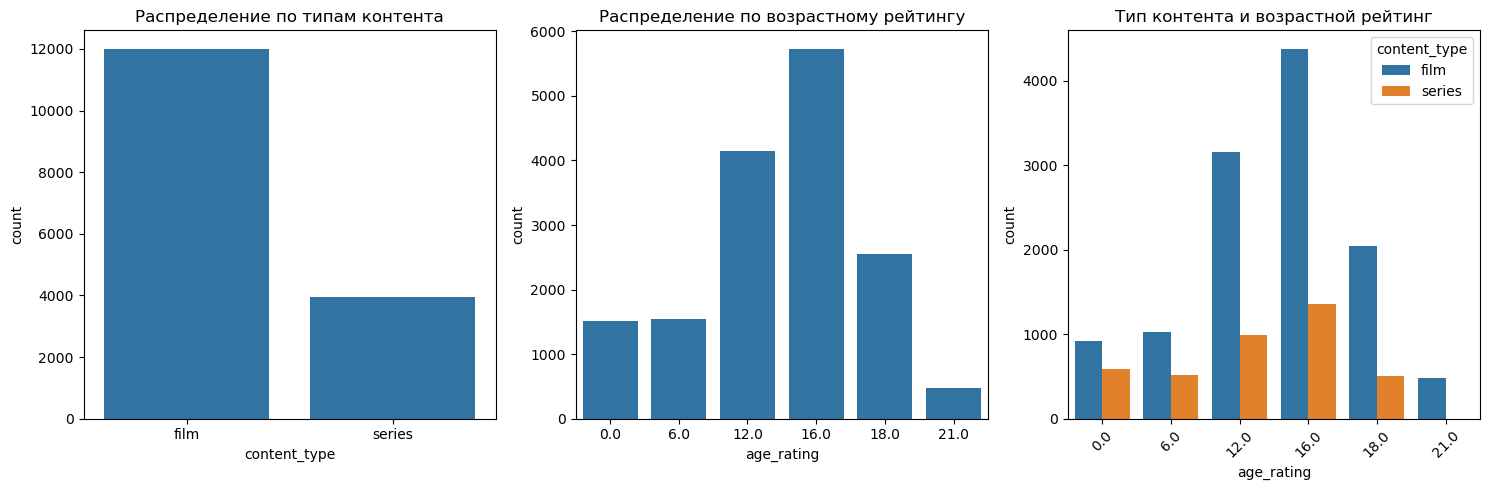

In [26]:
plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
sns.countplot(data=items, x='content_type')
plt.title('Распределение по типам контента')

plt.subplot(1, 3, 2)
sns.countplot(data=items, x='age_rating')
plt.title('Распределение по возрастному рейтингу')

plt.subplot(1, 3, 3)
plt.xticks(rotation=45)
sns.countplot(data=items, x='age_rating', hue='content_type')
plt.title('Тип контента и возрастной рейтинг')

plt.tight_layout()
plt.show()

count    15865.000000
mean      2007.932241
std         16.881118
min       1897.000000
25%       2007.000000
50%       2014.000000
75%       2018.000000
max       2021.000000
Name: release_year, dtype: float64


Text(0, 0.5, 'Количество')

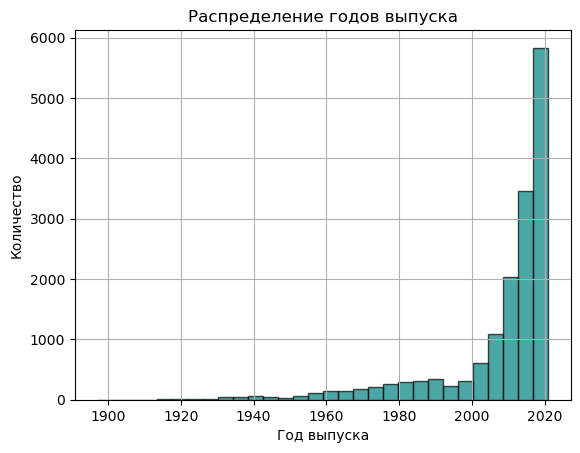

In [27]:
print(items['release_year'].describe())

items['release_year'].hist(bins=30, alpha=0.7, color='teal', edgecolor='black')
plt.title('Распределение годов выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Количество')

Всего уникальных жанров: 95


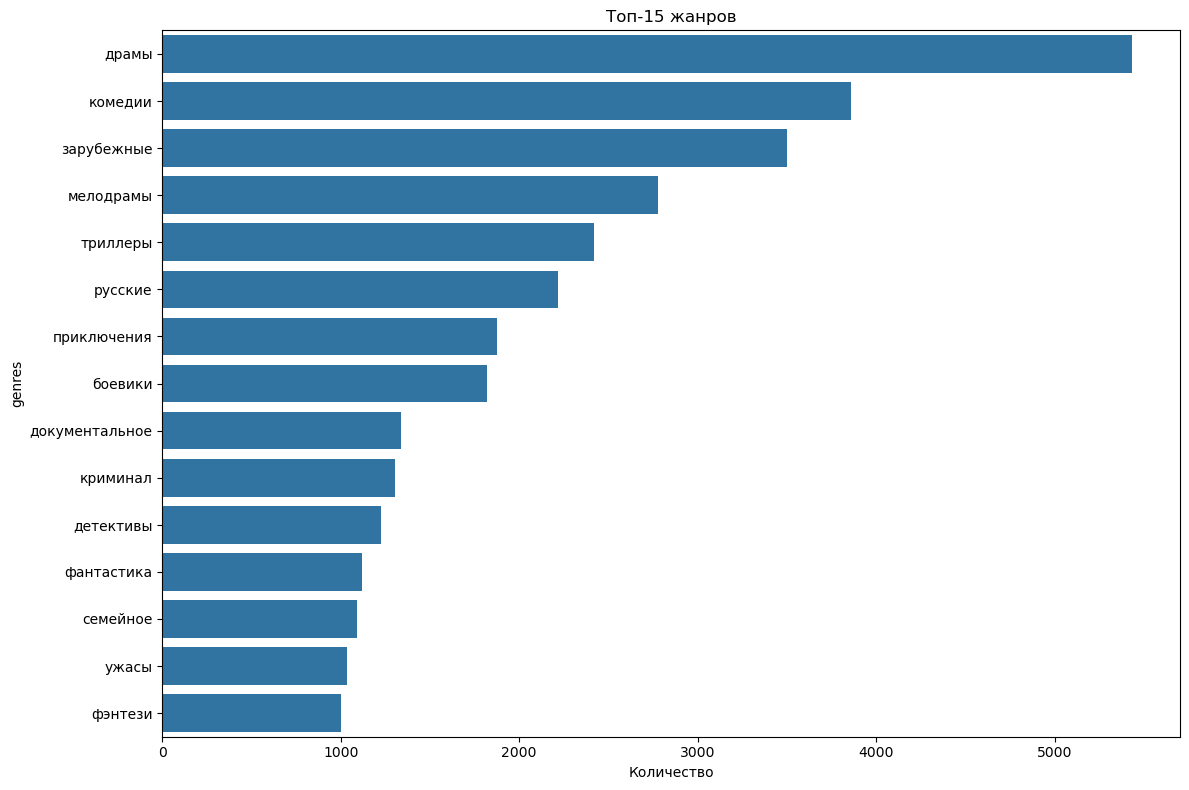


Среднее количество жанров на элемент: 2.55
Максимальное количество жанров: 9


In [28]:
if items['genres'].notna().any():
    all_genres = items['genres'].str.split(',').explode().str.strip()
    genre_counts = all_genres.value_counts()
    
    print(f"Всего уникальных жанров: {len(genre_counts)}")
    
    plt.figure(figsize=(12, 8))
    top_genres = genre_counts.head(15)
    sns.barplot(x=top_genres.values, y=top_genres.index)
    plt.title('Топ-15 жанров')
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.show()
    
    items['genre_count'] = items['genres'].str.split(',').apply(lambda x: len(x) if isinstance(x, list) else 0)
    print(f"\nСреднее количество жанров на элемент: {items['genre_count'].mean():.2f}")
    print(f"Максимальное количество жанров: {items['genre_count'].max()}")

Всего уникальных стран: 91


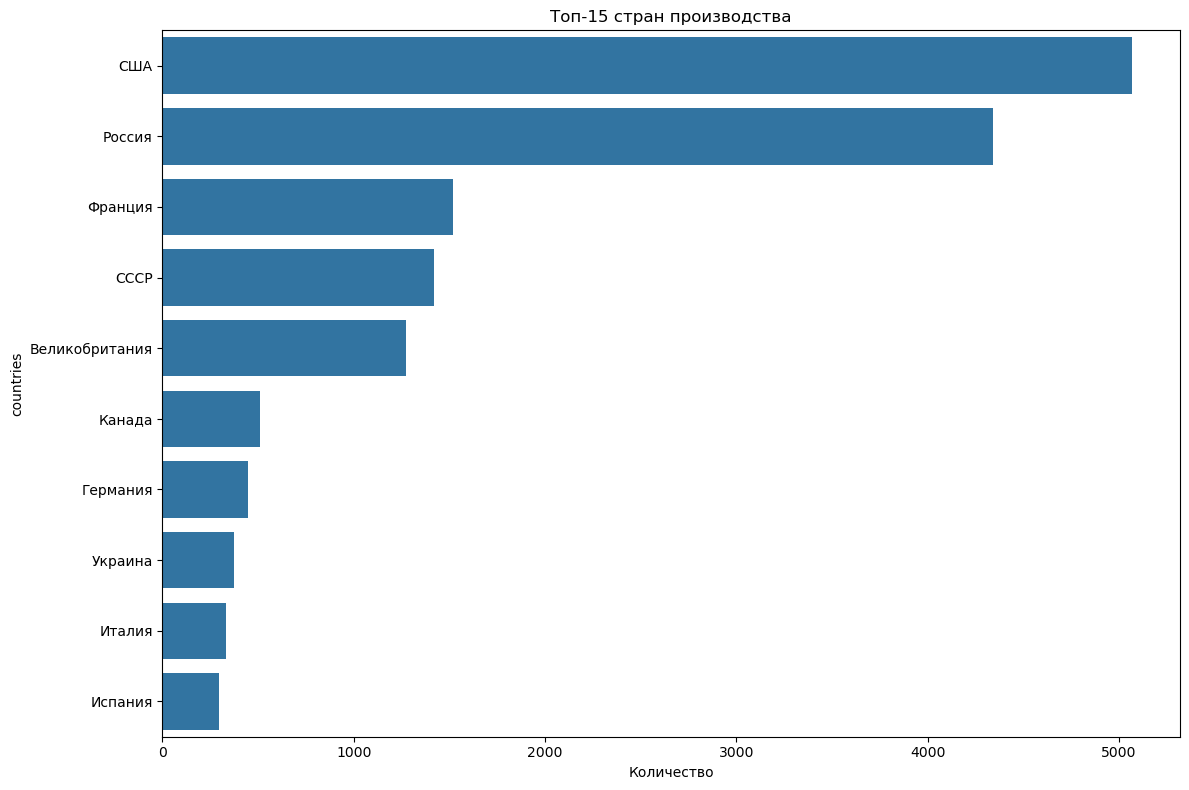

In [29]:
if items['countries'].notna().any():
    all_countries = items['countries'].str.split(',').explode().str.strip()
    country_counts = all_countries.value_counts()
    
    print(f"Всего уникальных стран: {len(country_counts)}")
    
    plt.figure(figsize=(12, 8))
    top_countries = country_counts.head(10)
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title('Топ-15 стран производства')
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.show()

In [30]:
old_item = items[items['release_year'] > 1960.0] # уберем старые фильмы до 1960 года
interactions = interactions[interactions['item_id'].isin(old_item['item_id'])]
interactions = interactions.drop(['total_dur'], axis=1, inplace=False) # уберем время просмотра

In [31]:
size_test = 1 # в test берем последнюю неделю
data = interactions[(interactions['watched_pct']>45.0)] # уберем фильмы с просмотром менее 25%
items_data = data['item_id'].value_counts()
active_items = items_data[items_data > 5].index # уберем фильмы с которыми взаимодействовали менее 5 раз
data = data[data['item_id'].isin(active_items)]
data_train = data[data['last_watch_dt'] < data['last_watch_dt'].max() - timedelta(weeks=size_test)]
data_test = data[data['last_watch_dt'] >= data['last_watch_dt'].max() - timedelta(weeks=size_test)]

In [32]:
train_sorted = data_train.sort_values(['user_id', 'last_watch_dt'])
    
train = train_sorted.groupby('user_id').tail(15) # у пользователей в train берем последние 15 фильмов

оставляем общих пользователей

In [33]:
test_users = set(data_test['user_id'].unique())
train_users = set(train['user_id'].unique())
common_users = test_users & train_users
    
print(f"Пользователей в test: {len(test_users)}")
print(f"Пользователей в train: {len(train_users)}")
print(f"Общих пользователей: {len(common_users)}")

Пользователей в test: 38924
Пользователей в train: 298891
Общих пользователей: 18630


In [34]:
user_interaction_test = data_test['user_id'].value_counts()
active_users_test = user_interaction_test[user_interaction_test > 1].index
test_active = data_test[data_test['user_id'].isin(active_users_test)]

user_interaction_train = train['user_id'].value_counts()
active_users_train = user_interaction_train[user_interaction_train > 1].index
train_active = train[train['user_id'].isin(active_users_train)]

test_users = test_active['user_id'].unique()
train_users = train_active['user_id'].unique()

data_train = train_active[train_active['user_id'].isin(test_users)]
data_test = test_active[test_active['user_id'].isin(train_users)]

In [35]:
test_users = set(data_test['user_id'].unique())
train_users = set(data_train['user_id'].unique())
common_users = test_users & train_users
    
print(f"Пользователей в test: {len(test_users)}")
print(f"Пользователей в train: {len(train_users)}")
print(f"Общих пользователей: {len(common_users)}")

Пользователей в test: 3868
Пользователей в train: 3868
Общих пользователей: 3868


### метрики

In [36]:
def precision(recommended_list, bought_list):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    flags = np.isin(bought_list, recommended_list)
    
    precision = flags.sum() / len(recommended_list)
    
    return precision


def precision_at_k(recommended_list, bought_list, k=5):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    bought_list = bought_list 
    recommended_list = recommended_list[:k]
    
    flags = np.isin(bought_list, recommended_list)
    
    precision = flags.sum() / len(recommended_list)
    
    
    return precision

def ap_k(recommended_list, bought_list, k=5):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    flags = np.isin(recommended_list, bought_list)
    
    if sum(flags) == 0:
        return 0
    
    sum_ = 0
    for i in range(0, k-1):
        if flags[i] == True:
            p_k = precision_at_k(recommended_list, bought_list, k=i+1)
            sum_ += p_k
            
    result = sum_ / sum(flags)
    
    return result

def map_k(recommended_list, bought_list, k=5, u=1):
    
    # your_code
    if u == 1:
        return ap_k(recommended_list[u-1], bought_list[u-1], k=5)
    
    sum = 0
    for i in range(0, u):
        ap_k_map = ap_k(recommended_list[i], bought_list[i], k=5)
        sum += ap_k_map

    result = sum / u
    
    return result

группируем в test фильмы по пользователям

In [37]:
data_test_group = data_test.groupby(data_test['user_id'])['item_id'].unique().reset_index()
data_test_group.columns = ['user_id', 'item_id']
data_test_group

,user_id,item_id
0,655,"[11188, 5199]"
1,753,"[9327, 3449]"
2,835,"[5434, 11640]"
3,858,"[6773, 6227]"
4,960,"[8636, 6809]"
...,...,...
3863,1096789,"[14317, 3908]"
3864,1097296,"[3006, 16087]"
3865,1097444,"[13650, 12841, 12250, 2483]"
3866,1097459,"[11844, 7793]"


In [38]:
userids = data_test_group['user_id'].values
 
userids_test = np.arange(len(userids))

### Popular

In [39]:
def popularity(train, n=10):
    train_group = train.groupby(train['item_id'])['user_id'].unique().reset_index()
    train_group.columns = ['item_id', 'user_id']

    train_group['user_sum'] = train_group['user_id'].apply(len)
    top_10_train = train_group.nlargest(n, 'user_sum')
    top_10 = top_10_train['item_id']

    return top_10.tolist()

popular = popularity(data_train, n=10)
result_popular = data_test_group.copy()
result_popular['popular_recommendation'] = result_popular['user_id'].apply(lambda x: popular)

In [40]:
print('popular map_k =', map_k(result_popular['popular_recommendation'], result_popular['item_id'], k=10, u=len(result_popular)))

popular map_k = 0.04956265081006551


### UserKNN

In [41]:
class UserKNN:
    def __init__(self, k=3, min_similarity=0.1):

        self.k = k
        self.min_similarity = min_similarity
        self.user_item_matrix = None
        self.user_similarity = None
        self.user_ids = None
        self.item_ids = None
        self.ratings_matrix = None
        
    def fit(self, interactions):

        self.matrix(interactions)
        self.similarity()
        
        return self
    
    def matrix(self, interactions):
        self.user_ids = pd.Categorical(interactions['user_id']).categories
        self.item_ids = pd.Categorical(interactions['item_id']).categories
        
        user_codes = pd.Categorical(interactions['user_id']).codes
        item_codes = pd.Categorical(interactions['item_id']).codes

        self.ratings_matrix = csr_matrix(
            (interactions['watched_pct'], (user_codes, item_codes)),
            shape=(len(self.user_ids), len(self.item_ids))
        )
        self.user_item_matrix = self.ratings_matrix.toarray()
        
        return self.ratings_matrix
    
    def similarity(self):
        self.user_similarity = cosine_similarity(self.user_item_matrix)
        np.fill_diagonal(self.user_similarity, 0)
        
        return self.user_similarity
    
    def user_index(self, user_id):
        if user_id not in self.user_ids:
            return None
        return np.where(self.user_ids == user_id)[0][0]
    
    def item_index(self, item_id):
        if item_id not in self.item_ids:
            return None
        return np.where(self.item_ids == item_id)[0][0]
    
    def similar_users(self, user_id, n_similar=None):
        if n_similar is None:
            n_similar = self.k
            
        user_idx = self.user_index(user_id)
        if user_idx is None:
            return []
        
        user_similarities = self.user_similarity[user_idx]
        similar_indices = np.argsort(user_similarities)[::-1]

        similar_users = []
        for idx in similar_indices:
            similarity = user_similarities[idx]
            if similarity >= self.min_similarity and len(similar_users) < n_similar:
                similar_user_id = self.user_ids[idx]
                similar_users.append((similar_user_id, similarity))
            elif len(similar_users) >= n_similar:
                break
        
        return similar_users
    
    def predict(self, user_id, item_id):
        user_idx = self.user_index(user_id)
        item_idx = self.item_index(item_id)
        
        if user_idx is None or item_idx is None:
            return 0.0

        similar_users = self.similar_users(user_id)
        
        if not similar_users:
            return 0.0

        neighbor_ratings = []
        neighbor_similarities = []
        
        for neighbor_id, similarity in similar_users:
            neighbor_idx = self.user_index(neighbor_id)
            neighbor_rating = self.user_item_matrix[neighbor_idx, item_idx]

            if neighbor_rating > 0:
                neighbor_ratings.append(neighbor_rating)
                neighbor_similarities.append(similarity)

        if not neighbor_ratings:
            return 0.0

        neighbor_ratings = np.array(neighbor_ratings)
        neighbor_similarities = np.array(neighbor_similarities)

        if np.sum(neighbor_similarities) > 0:
            predicted_rating = np.average(neighbor_ratings, weights=neighbor_similarities)
        else:
            predicted_rating = np.mean(neighbor_ratings)
        
        return float(predicted_rating)
    
    def recommend(self, user_id, n_recommendations=10):

        user_idx = self.user_index(user_id)
        if user_idx is None:
            return []

        user_ratings = self.user_item_matrix[user_idx]
        rated_items = set(np.where(user_ratings > 0)[0])

        predictions = []
        for item_idx in range(len(self.item_ids)):
            if item_idx not in rated_items:
                item_id = self.item_ids[item_idx]
                predicted_rating = self.predict(user_id, item_id)
                
                if predicted_rating > 0:
                    predictions.append((item_id, predicted_rating))

        predictions.sort(key=lambda x: x[1], reverse=True)
        
        return [item_id for item_id, _ in predictions[:n_recommendations]]

In [42]:
model_UserKNN = UserKNN(k=17, min_similarity=0.15)
model_UserKNN.fit(data_train)

In [43]:
recos_user = []
for i in range(len(userids_test)):
   recommendations = model_UserKNN.recommend(userids[i], n_recommendations=10)
   recos_user.append({'item_id': recommendations})

result_user_knn = pd.DataFrame(recos_user, userids).reset_index()
result_user_knn


,index,item_id
0,655,"[3784, 5046, 5803, 6809, 11204, 13955, 902, 93..."
1,753,"[11363, 14361, 15297, 15648, 1000, 7310, 12995..."
2,835,"[142, 3734, 4495, 4946, 5505, 6661, 8254, 9900..."
3,858,"[1819, 6561, 7626, 8636, 9900, 11237, 10240, 4..."
4,960,"[13159, 15297, 2823, 2190, 16228, 512, 5315, 1..."
...,...,...
3863,1096789,"[5693, 9164, 565, 3940, 3943, 5716, 5754, 6561..."
3864,1097296,"[3190, 9314, 16346, 288, 1000, 1351, 3935, 540..."
3865,1097444,"[47, 281, 1857, 1995, 3095, 3940, 4635, 6219, ..."
3866,1097459,"[542, 2048, 3153, 6455, 14461, 6809, 7971, 445..."


In [45]:
print('UserKNN_map_k =', map_k(result_user_knn['item_id'], data_test_group['item_id'], k=10, u=len(data_test_group)))

UserKNN_map_k = 0.012883488452257843


### LightFM

In [46]:
data_test.rename(columns={'user_id': Columns.User, 'item_id': Columns.Item, 
                                'last_watch_dt': Columns.Datetime, 'watched_pct': Columns.Weight},inplace=True)


data_train.rename(columns={'user_id': Columns.User, 'item_id': Columns.Item, 
                                'last_watch_dt': Columns.Datetime, 'watched_pct': Columns.Weight},inplace=True)

/var/folders/qs/gxy4f99x26l7w88l0zk12_w00000gn/T/ipykernel_1728/2957829531.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test.rename(columns={'user_id': Columns.User, 'item_id': Columns.Item,
/var/folders/qs/gxy4f99x26l7w88l0zk12_w00000gn/T/ipykernel_1728/2957829531.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train.rename(columns={'user_id': Columns.User, 'item_id': Columns.Item,


In [47]:
dataset_tr = dataset.Dataset.construct(data_train)

In [48]:
from rectools.models import LightFMWrapperModel
from lightfm import LightFM

model = LightFMWrapperModel(
        epochs=100,
        num_threads=10,
        model=LightFM(no_components = 50, learning_rate=0.001, loss='warp')
        )

/opt/anaconda3/lib/python3.12/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


In [49]:
users_unique = data_test[Columns.User].unique()
model.fit(dataset_tr)
recos = model.recommend(
    users=users_unique,
    dataset=dataset_tr,
    k = 10,
    filter_viewed= True 
)

In [50]:
recos

,user_id,item_id,score,rank
0,45247,9728,0.380865,1
1,45247,13865,0.313692,2
2,45247,3734,0.294583,3
3,45247,15297,0.275908,4
4,45247,10440,0.270765,5
...,...,...,...,...
38675,612350,3182,0.211836,6
38676,612350,7571,0.208779,7
38677,612350,142,0.200923,8
38678,612350,8636,0.197816,9


In [51]:
result_recom = recos.groupby(recos['user_id'])['item_id'].unique().reset_index()
result_recom.columns = ['user_id', 'item_id']
result_recom

,user_id,item_id
0,655,"[9728, 3734, 13865, 15297, 10440, 142, 4151, 8..."
1,753,"[9728, 13865, 3734, 10440, 15297, 4151, 8636, ..."
2,835,"[13865, 3734, 10440, 8636, 4151, 142, 7571, 31..."
3,858,"[9728, 3734, 13865, 15297, 10440, 8636, 7571, ..."
4,960,"[9728, 3734, 13865, 15297, 8636, 4151, 7571, 1..."
...,...,...
3863,1096789,"[9728, 13865, 3734, 10440, 15297, 8636, 4151, ..."
3864,1097296,"[9728, 13865, 3734, 10440, 15297, 142, 7571, 8..."
3865,1097444,"[9728, 13865, 3734, 15297, 10440, 7571, 8636, ..."
3866,1097459,"[9728, 3734, 10440, 15297, 8636, 7571, 4151, 3..."


In [52]:
print('map_k =', map_k(result_recom['item_id'], data_test_group['item_id'], k=10, u=len(data_test_group)))

map_k = 0.05319286452947262


### рекомендации для случайных пользователей

In [53]:
data_train_group = data_train.groupby(data_train['user_id'])['item_id'].unique().reset_index()
data_train_group.columns = ['user_id', 'item_id']
data_train_group

,user_id,item_id
0,655,"[6273, 4946, 15531, 11899]"
1,753,"[14814, 14242, 6377, 9194, 10219, 12516, 2612,..."
2,835,"[13159, 15297, 6143, 3792, 9728, 9615, 12692, ..."
3,858,"[1844, 2916, 2100, 11406, 3878, 7057, 13167, 1..."
4,960,"[10440, 1527, 14915, 8618, 12770]"
...,...,...
3863,1096789,"[12173, 7626]"
3864,1097296,"[4740, 7424]"
3865,1097444,"[144, 2925, 6825, 10038, 5336, 9811, 7444, 844..."
3866,1097459,"[9222, 14095, 9213, 4040, 3792, 13865, 6210, 5..."


In [68]:
random_user1 = np.random.choice(data_test['user_id'], replace=False)
random_user2 = np.random.choice(data_test['user_id'], replace=False)
random_user3 = np.random.choice(data_test['user_id'], replace=False)

In [69]:
rec_user = result_user_knn.loc[result_user_knn['index']==random_user1, 'item_id'].iloc[0]
rec_item = result_recom.loc[result_recom['user_id']==random_user1, 'item_id'].iloc[0]
rec_test = data_test_group.loc[data_test_group['user_id']==random_user1, 'item_id'].iloc[0]
rec_train = data_train_group.loc[data_train_group['user_id']==random_user1, 'item_id'].iloc[0]

pred_user = []
test = []
pred_item = []
train = []

for i in range(len(rec_user)):
    title_item = items.loc[items['item_id']==rec_user[i], 'title'].iloc[0]
    pred_user.append(title_item)

for i in range(len(rec_item)):
    title_item = items.loc[items['item_id']==rec_item[i], 'title'].iloc[0]
    pred_item.append(title_item)

for i in range(len(rec_test)):
    title_item = items.loc[items['item_id']==rec_test[i], 'title'].iloc[0]
    test.append(title_item)

for i in range(len(rec_train)):
    title_item = items.loc[items['item_id']==rec_train[i], 'title'].iloc[0]
    train.append(title_item)


print(f"Рекомендаций для пользователя {random_user1}:") 
print('UserKNN')
for i, (item) in enumerate(zip(pred_user)):
    print(f"{i+1}. {item}")
print('LightFM')
for i, (item) in enumerate(zip(pred_item)):
    print(f"{i+1}. {item}")
print('Test')
for i, (item) in enumerate(zip(test)):
    print(f"{i+1}. {item}")
print('Train')
for i, (item) in enumerate(zip(train)):
    print(f"{i+1}. {item}")

Рекомендаций для пользователя 208055:
UserKNN
1. ('Дивергент',)
2. ('Мстители: Финал',)
3. ('Дочь якудзы',)
4. ('Гнев человеческий',)
5. ('Чёрная пантера',)
6. ('Игра',)
7. ('Прабабушка легкого поведения',)
8. ('Дуров',)
9. ('2067: Петля времени',)
10. ('Секреты семейной жизни',)
LightFM
1. ('Гнев человеческий',)
2. ('Прабабушка легкого поведения',)
3. ('Хрустальный',)
4. ('Клиника счастья',)
5. ('Белый снег',)
6. ('Секреты семейной жизни',)
7. ('100% волк',)
8. ('Ральф против Интернета',)
9. ('Маша',)
10. ('Тайна Коко',)
Test
1. ('Агент под прикрытием',)
2. ('Прабабушка легкого поведения',)
3. ('Братство',)
Train
1. ('Девятаев',)
2. ('Пальмира',)
3. ('Гостиница “Россия”',)
4. ('Крёстная мама',)
5. ('Холодильник',)


In [70]:
rec_user = result_user_knn.loc[result_user_knn['index']==random_user2, 'item_id'].iloc[0]
rec_item = result_recom.loc[result_recom['user_id']==random_user2, 'item_id'].iloc[0]
rec_test = data_test_group.loc[data_test_group['user_id']==random_user2, 'item_id'].iloc[0]
rec_train = data_train_group.loc[data_train_group['user_id']==random_user2, 'item_id'].iloc[0]

pred_user = []
test = []
pred_item = []
train = []

for i in range(len(rec_user)):
    title_item = items.loc[items['item_id']==rec_user[i], 'title'].iloc[0]
    pred_user.append(title_item)

for i in range(len(rec_item)):
    title_item = items.loc[items['item_id']==rec_item[i], 'title'].iloc[0]
    pred_item.append(title_item)

for i in range(len(rec_test)):
    title_item = items.loc[items['item_id']==rec_test[i], 'title'].iloc[0]
    test.append(title_item)

for i in range(len(rec_train)):
    title_item = items.loc[items['item_id']==rec_train[i], 'title'].iloc[0]
    train.append(title_item)


print(f"Рекомендаций для пользователя {random_user2}:") 
print('UserKNN')
for i, (item) in enumerate(zip(pred_user)):
    print(f"{i+1}. {item}")
print('LightFM')
for i, (item) in enumerate(zip(pred_item)):
    print(f"{i+1}. {item}")
print('Test')
for i, (item) in enumerate(zip(test)):
    print(f"{i+1}. {item}")
print('Train')
for i, (item) in enumerate(zip(train)):
    print(f"{i+1}. {item}")

Рекомендаций для пользователя 114279:
UserKNN
1. ('Гадкий я',)
2. ('Хатико: Самый верный друг',)
3. ('Ледниковый период 3: Эра динозавров',)
4. ('Город героев',)
5. ('Три богатыря. Ход конем',)
6. ('Форсаж 8',)
7. ('Семейка Крудс',)
8. ('Я худею',)
9. ('Мулан',)
10. ('Ральф против Интернета',)
LightFM
1. ('Гнев человеческий',)
2. ('Девятаев',)
3. ('Прабабушка легкого поведения',)
4. ('Клиника счастья',)
5. ('Хрустальный',)
6. ('100% волк',)
7. ('Секреты семейной жизни',)
8. ('Ральф против Интернета',)
9. ('Белый снег',)
10. ('Монстры на каникулах 3: Море зовёт',)
Test
1. ('Мадагаскар',)
2. ('В поисках Немо',)
3. ('Дэдпул',)
4. ('Погребённый заживо',)
5. ('Холодное сердце II',)
Train
1. ('Жестокий Стамбул',)
2. ('ВАЛЛ-И',)
3. ('Заражённая',)
4. ('Алеша Попович и Тугарин Змей',)
5. ('Кот Гром и заколдованный дом',)
6. ('Время монстров',)
7. ('Корпорация монстров',)
8. ('Рататуй',)
9. ('Суперсемейка 2',)
10. ('Мстители: Война бесконечности',)
11. ('Лига Watchcar - Песни о безопасности на 

In [71]:
rec_user = result_user_knn.loc[result_user_knn['index']==random_user3, 'item_id'].iloc[0]
rec_item = result_recom.loc[result_recom['user_id']==random_user3, 'item_id'].iloc[0]
rec_test = data_test_group.loc[data_test_group['user_id']==random_user3, 'item_id'].iloc[0]
rec_train = data_train_group.loc[data_train_group['user_id']==random_user3, 'item_id'].iloc[0]

pred_user = []
test = []
pred_item = []
train = []

for i in range(len(rec_user)):
    title_item = items.loc[items['item_id']==rec_user[i], 'title'].iloc[0]
    pred_user.append(title_item)

for i in range(len(rec_item)):
    title_item = items.loc[items['item_id']==rec_item[i], 'title'].iloc[0]
    pred_item.append(title_item)

for i in range(len(rec_test)):
    title_item = items.loc[items['item_id']==rec_test[i], 'title'].iloc[0]
    test.append(title_item)

for i in range(len(rec_train)):
    title_item = items.loc[items['item_id']==rec_train[i], 'title'].iloc[0]
    train.append(title_item)


print(f"Рекомендаций для пользователя {random_user3}:") 
print('UserKNN')
for i, (item) in enumerate(zip(pred_user)):
    print(f"{i+1}. {item}")
print('LightFM')
for i, (item) in enumerate(zip(pred_item)):
    print(f"{i+1}. {item}")
print('Test')
for i, (item) in enumerate(zip(test)):
    print(f"{i+1}. {item}")
print('Train')
for i, (item) in enumerate(zip(train)):
    print(f"{i+1}. {item}")

Рекомендаций для пользователя 361652:
UserKNN
1. ('Тайна Коко',)
2. ('Заложница 3',)
3. ('Бывшая с того света',)
4. ('Движение вверх',)
5. ('Капитан Марвел',)
6. ('Люди Икс: Дни минувшего будущего',)
7. ('Люди Икс: Апокалипсис',)
8. ('Гнев человеческий',)
9. ('Мы – монстры',)
10. ('Мстители: Финал',)
LightFM
1. ('Гнев человеческий',)
2. ('Девятаев',)
3. ('Прабабушка легкого поведения',)
4. ('Хрустальный',)
5. ('Клиника счастья',)
6. ('Белый снег',)
7. ('100% волк',)
8. ('Секреты семейной жизни',)
9. ('Ральф против Интернета',)
10. ('Маша',)
Test
1. ('Анастасия',)
2. ('Мстители',)
Train
1. ('Золушка (2015)',)
2. ('Доктор Стрэндж',)
3. ('Мстители: Война бесконечности',)
